# Car Price Prediction Project

## Data Loading



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

#load dataset
df = pd.read_csv('..\car_price_prediction.csv')

## 1. Initial Data Exploration

The goal of this step is to understand the structure of the dataset, including feature types, basic statistics, and initial data quality.

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              19237 non-null  str    
 3   Manufacturer      19237 non-null  str    
 4   Model             19237 non-null  str    
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  str    
 7   Leather interior  19237 non-null  str    
 8   Fuel type         19237 non-null  str    
 9   Engine volume     19237 non-null  str    
 10  Mileage           19237 non-null  str    
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  str    
 13  Drive wheels      19237 non-null  str    
 14  Doors             19237 non-null  str    
 15  Wheel             19237 non-null  str    
 16  Color             19237 non-null  str    
 17  Airb

In [3]:
df.describe()

,ID,Price,Prod. year,Cylinders,Airbags
count,1.923700e+04,1.923700e+04,19237.000000,19237.000000,19237.000000
mean,4.557654e+07,1.855593e+04,2010.912824,4.582991,6.582627
std,9.365914e+05,1.905813e+05,5.668673,1.199933,4.320168
min,2.074688e+07,1.000000e+00,1939.000000,1.000000,0.000000
25%,4.569837e+07,5.331000e+03,2009.000000,4.000000,4.000000
50%,4.577231e+07,1.317200e+04,2012.000000,4.000000,6.000000
75%,4.580204e+07,2.207500e+04,2015.000000,4.000000,12.000000
max,4.581665e+07,2.630750e+07,2020.000000,16.000000,16.000000


In [4]:
df.head()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


## Initial observations:

 - There are no Na values; however, non-existent values such as “ - ” were observed in the *Levy column.
 - There is poorly formatted information in the *Doors and *Mileage columns.
 - There are absurd values for *Price and *mileage that are far outside the average, with possible discrepancies.

## Check the chart for outliers in the identified columns.
- Columns *Price and *Mileage

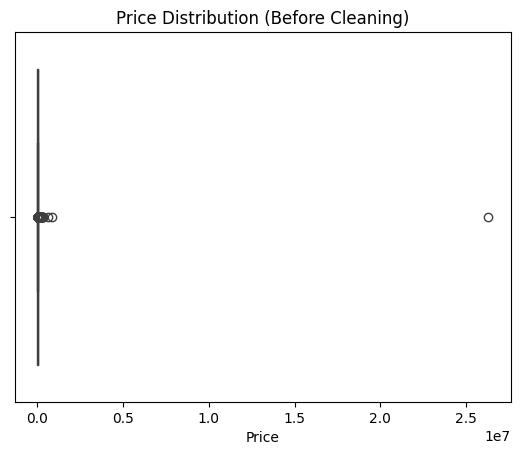

In [5]:
sns.boxplot(x=df["Price"])
plt.title("Price Distribution (Before Cleaning)")
plt.show()

The price distribution shows extreme values, indicating the presence of outliers.

### Mileage Formatting

The Mileage feature is stored as a string and requires conversion to numeric format.

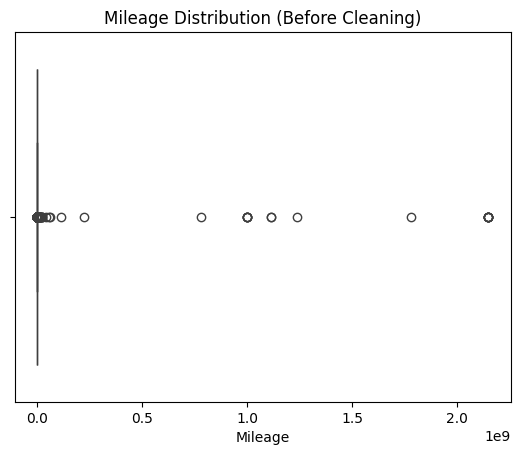

In [6]:
#Correct formatting of mileage data
df["Mileage"] = df["Mileage"].str.extract("(\d+)").astype(float)

#Plot the information of Mileage
sns.boxplot(x=df["Mileage"])
plt.title("Mileage Distribution (Before Cleaning)")
plt.show()

Mileage also contains extreme and unrealistic values, which may represent data entry issues.

### Outlier Treatment

To reduce the impact of extreme values, a filtering approach is applied to both Price and Mileage.

In [7]:
#Price filtering
absurd_price = df["Price"].quantile(0.99)
low_price = df["Price"].quantile(0.1)

#Price and km filterinf by Dataset
df_clean = df[
    (df["Price"] < absurd_price) &
    (df["Price"] > low_price) &
    (df["Mileage"] <= 500000)]

### Graphical price and mileage validation

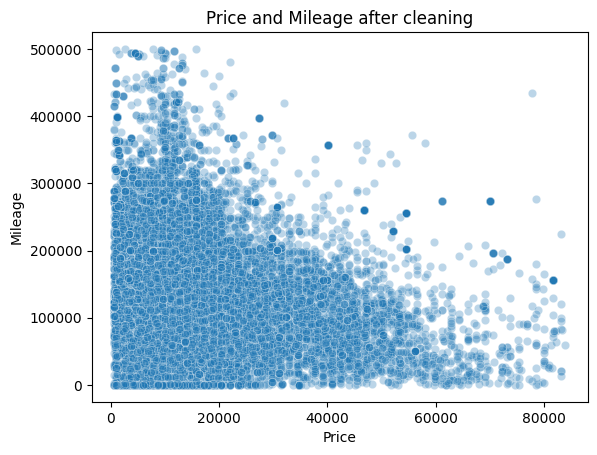

In [8]:
sns.scatterplot(x=df_clean["Price"],y=df_clean["Mileage"], alpha=0.3)
plt.title("Price and Mileage after cleaning")
plt.show()

It is now possible,in graph, the mileage and price figures are within realistic ranges after the cleaning.

## Feacture Cleaning and Formatting

### Removing Irrelevant Features

Some columns do not provide useful information for the prediction task or contain a high proportion of missing or inconsistent values.

For example, the *Levy* column contains a large number of non-standard missing values (represented as "-"), accounting for a significant portion of the dataset. Due to this, the feature is considered unreliable and is removed.

Additionally, the *Wheel* feature is removed as it is not expected to contribute meaningfully to price prediction.

In [9]:
(df["Levy"] =="-").sum()
# Check missing-like values in Levy (approximately 30%)

np.int64(5819)

In [10]:
# Drop irrelevant columns
df_clean = df.drop(columns=["Levy","Wheel"])

### Formatting Doors
The *Doors* feature contains inconsistent categorical values (e.g. "02-Mar", "04-May", ">5"), which are not suitable for modeling.

These values are mapped into a standardized numeric format.


In [11]:
df["Doors"].unique()

<StringArray>
['04-May', '02-Mar', '>5']
Length: 3, dtype: str

In [12]:
mapa={
    '04-May': 4, 
    '02-Mar': 2,
    '>5':6
}

df_clean["Doors"]= df["Doors"].map(mapa).astype(float)

### Formatting Eng Volume

parameters will be formatted as integers and floats only, removing any string values if present.

In [13]:
df_clean["Engine volume"] = df["Engine volume"].str.extract("(\d+)").astype(float)

## Handling Duplicates

Duplicate records can negatively impact model performance and introduce bias. Therefore, duplicates are identified and removed.

The duplicated will be identify by *ID* column.

In [14]:
# Number of duplicates values
df_clean["ID"].duplicated().sum()

np.int64(313)

In [15]:
#remove the duplicates valuers
df_clean = df_clean.drop_duplicates(subset="ID")

In [16]:
#check of removed
df_clean["ID"].duplicated().sum()

np.int64(0)

## Eda final

Exploratory Data Analysis (Cleaned Data).
In this section, we analyze the cleaned dataset to identify patterns and relationships between key variables relevant to price prediction.

### Price Distribution by Manufacturer

We analyze how car prices vary across different manufacturers.

In [17]:
#after 2000
top_brands = df_clean[df_clean["Prod. year"]>=2000]
#counts of each Manufacturer
top_brands = top_brands["Manufacturer"].value_counts().head(10).index
df_top = df_clean[df_clean["Manufacturer"].isin(top_brands)]

In [18]:
#counts of car each Manufacturer
df_top["Manufacturer"].value_counts()

Manufacturer
HYUNDAI          3729
TOYOTA           3606
MERCEDES-BENZ    2043
FORD             1088
CHEVROLET        1047
BMW              1036
HONDA             960
LEXUS             927
NISSAN            645
VOLKSWAGEN        571
Name: count, dtype: int64

#### Price Distribution by Manufacturer

The distribution of car prices varies significantly across manufacturers.

Premium brands such as Mercedes-Benz and BMW exhibit higher price ranges and greater variability, reflecting the presence of both standard and high-end models. In contrast, brands like Hyundai, Nissan, and Volkswagen tend to have lower and more concentrated price distributions.

A considerable number of high-value observations are present across most manufacturers. Given that the dataset represents used cars, these values are likely associated with low-mileage vehicles or higher-end configurations rather than data errors.

Overall, the manufacturer plays an important role in price determination; however, the wide variability within brands suggests that additional factors, such as mileage and model, also strongly influence pricing.

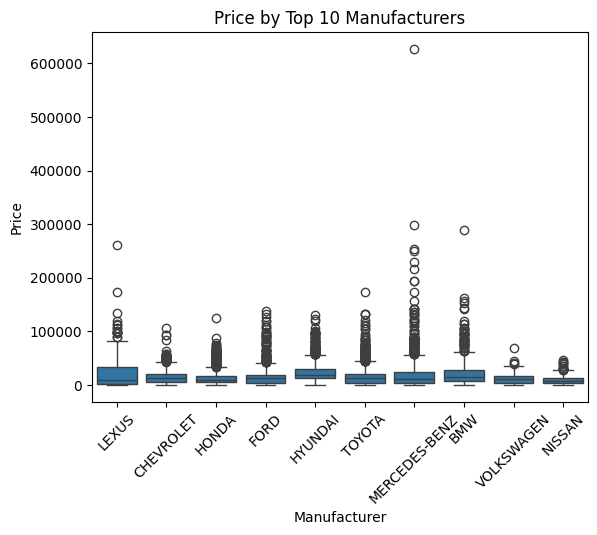

In [19]:
#plot 
sns.boxplot(x="Manufacturer", y="Price", data=df_top)
plt.xticks(rotation=45)
plt.title("Price by Top 10 Manufacturers")
plt.show()

### Average Mileage by Manufacturer

We analyze the average mileage of cars across different manufacturers to understand usage patterns in the market.

#### Average Mileage by Manufacturer

The average mileage varies significantly across manufacturers.

Brands such as Volkswagen, BMW, and Nissan show higher average mileage, which may indicate that these vehicles are more commonly used over longer periods before being listed for sale.

In contrast, brands like Lexus, Hyundai, and Honda exhibit lower average mileage, which could suggest that these vehicles are either newer, less frequently used, or sold earlier in their lifecycle.

These differences likely reflect market behavior and usage patterns rather than intrinsic vehicle quality.

Overall, mileage appears to be influenced by how different brands are used and positioned in the market.

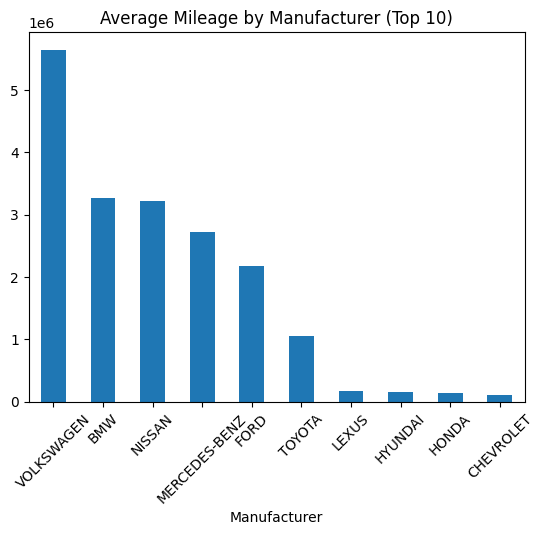

In [20]:
top_brands = df_clean["Manufacturer"].value_counts().head(10).index
df_top = df_clean[df_clean["Manufacturer"].isin(top_brands)]

df_top.groupby("Manufacturer")["Mileage"].mean().sort_values(ascending=False).plot(kind="bar")
plt.title("Average Mileage by Manufacturer (Top 10)")
plt.xticks(rotation=45)
plt.show()

### Correlation Analysis

The correlation matrix shows generally weak linear relationships between most numerical variables and the target variable (*Price*).

In particular, *Mileage* and *Price* exhibit a very low correlation, suggesting that their relationship may not be strictly linear. Similarly, other features such as *Engine volume*, *Cylinders*, and *Doors* show minimal direct linear influence on price.

A moderate correlation is observed between *Engine volume* and *Cylinders*, which is expected, as these features are mechanically related.

Overall, the absence of strong linear correlations suggests that price prediction is likely influenced by a combination of multiple factors, including categorical variables such as manufacturer and model.

This indicates that more complex or non-linear models may be required to capture these relationships effectively.

<Axes: >

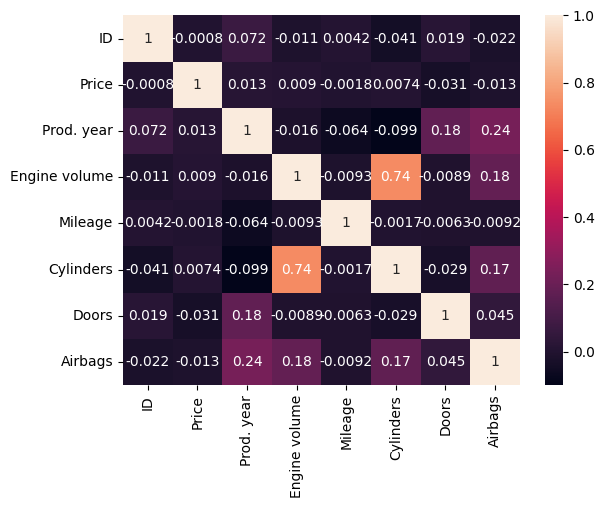

In [21]:
sns.heatmap(df_clean.corr(numeric_only=True),annot=True)

## Linear Regression

We will train all the parameters using the ID that will be removed. The goal is to predict the price based on the given variables.

To achieve this, there will be a preprocessing step involving both numerical and non-numerical features.

In [37]:
# set the variabel for our train

X = df_clean.drop(columns=["ID","Price"])
y = df_clean["Price"]

,ID,Price,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Color,Airbags
0,45654403,13328,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.0,186005.0,6.0,Automatic,4x4,4.0,Silver,12
1,44731507,16621,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3.0,192000.0,6.0,Tiptronic,4x4,4.0,Black,8
2,45774419,8467,HONDA,FIT,2006,Hatchback,No,Petrol,1.0,200000.0,4.0,Variator,Front,4.0,Black,2
3,45769185,3607,FORD,Escape,2011,Jeep,Yes,Hybrid,2.0,168966.0,4.0,Automatic,4x4,4.0,White,0
4,45809263,11726,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.0,91901.0,4.0,Automatic,Front,4.0,Silver,4


In [38]:
#Columns
numeric_features = ["Prod. year", "Engine volume",	"Mileage",	"Cylinders", "Doors",	"Airbags"]
categorical_features = ["Manufacturer",	"Model", "Category",	"Leather interior","Fuel type",	"Gear box type", "Drive wheels",	"Color"]

#pre-processes
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

In [40]:
# pipeline complet
model = Pipeline([
    ("prep", preprocessor),
    ("reg", LinearRegression())
])

# treino/teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model.fit(X_train, y_train)

pred = model.predict(X_test)
print(pred[:5])

[18708.52675634 18709.02547102 18708.58371214 18708.55200544
 18708.26664514]


In [42]:
#intercept
model.named_steps["reg"].intercept_
#Intercept represents the predicted price when all features are zero (rarely meaningful in real-world interpretation).

np.float64(18710.38042511)

In [45]:
#Verification of the coefficients for each attribute of the found function
import pandas as pd

coef_df = pd.DataFrame({
    "feature": model.named_steps["prep"].get_feature_names_out(),
    "coef": model.named_steps["reg"].coef_
})

print(coef_df.sort_values(by="coef", ascending=False).head(10))

                           feature          coef
1475               num__Prod. year  5.867529e-12
1446         cat__Fuel type_Diesel  2.109574e-12
480               cat__Model_Combo  1.274012e-12
1434     cat__Category_Goods wagon  1.211063e-12
41          cat__Manufacturer_OPEL  1.104582e-12
1461               cat__Color_Blue  1.065330e-12
1436            cat__Category_Jeep  9.497944e-13
1478                num__Cylinders  8.825064e-13
1454  cat__Gear box type_Tiptronic  7.847274e-13
1453     cat__Gear box type_Manual  7.665251e-13
